In [1]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import recall_score, roc_auc_score, roc_curve

from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [35]:
from google.colab import files
uploaded = files.upload()

Saving loan_data.csv to loan_data (1).csv


In [36]:
#Load Dataset

df = pd.read_csv("loan_data.csv")

In [37]:
#Explore dataset

print("Shape of dataset:", df.shape)
print(df.head())

Shape of dataset: (307511, 122)
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ..

In [38]:
# Missing values

missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

In [39]:
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
}).sort_values(by='Missing %', ascending=False)

print("\nTop Missing Columns:\n", missing_df.head(10))


Top Missing Columns:
                           Missing Count  Missing %
COMMONAREA_AVG                   214865  69.872297
COMMONAREA_MODE                  214865  69.872297
COMMONAREA_MEDI                  214865  69.872297
NONLIVINGAPARTMENTS_MEDI         213514  69.432963
NONLIVINGAPARTMENTS_MODE         213514  69.432963
NONLIVINGAPARTMENTS_AVG          213514  69.432963
FONDKAPREMONT_MODE               210295  68.386172
LIVINGAPARTMENTS_AVG             210199  68.354953
LIVINGAPARTMENTS_MEDI            210199  68.354953
LIVINGAPARTMENTS_MODE            210199  68.354953


In [40]:
# Drop Columns with >50% Missing

cols_to_drop = missing_percent[missing_percent > 50].index
df = df.drop(columns=cols_to_drop)

print("Shape after dropping columns:", df.shape)

Shape after dropping columns: (307511, 81)


In [41]:
#Target Distribution

print("\nTarget Distribution:\n", df['TARGET'].value_counts())
print("\nTarget Percentage:\n", df['TARGET'].value_counts(normalize=True) * 100)



Target Distribution:
 TARGET
0    282686
1     24825
Name: count, dtype: int64

Target Percentage:
 TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


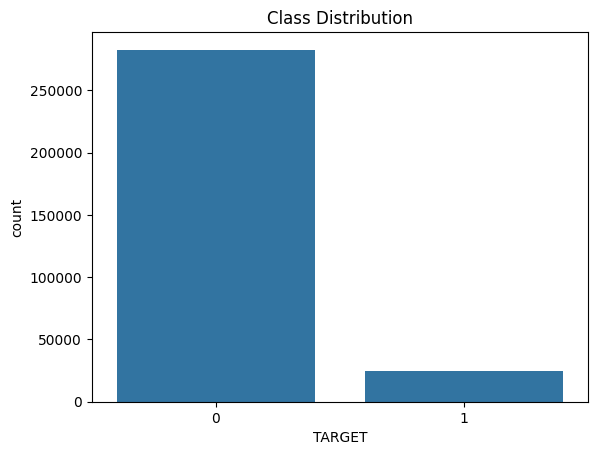

In [42]:
#Plot

sns.countplot(x='TARGET', data=df)
plt.title("Class Distribution")
plt.show()

In [43]:
#Separate Features & Target

X = df.drop('TARGET', axis=1)
y = df['TARGET']

print(X.shape, y.shape)

(307511, 80) (307511,)


In [44]:
#Encode Categorical Columns

le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col].astype(str))

print("Encoding done")

Encoding done


In [45]:
#Handle Missing Values

X = X.fillna(X.median())

print("Remaining nulls:", X.isnull().sum().sum())

Remaining nulls: 0


In [46]:
#Handle Imbalanced Data (SMOTE)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("\nAfter SMOTE:\n", pd.Series(y_res).value_counts())


After SMOTE:
 TARGET
1    282686
0    282686
Name: count, dtype: int64


In [47]:
#Feature Scaling

scaler = StandardScaler()
X_res = scaler.fit_transform(X_res)

print("Scaling complete")

Scaling complete


In [48]:
#Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(452297, 80) (113075, 80)


In [49]:
#Build Deep Learning Model

model = Sequential([
    Dense(128, activation='relu', input_dim=X_train.shape[1]),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,689 (73.00 KB)

 Trainable params: 18,689 (73.00 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
#Train Model

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
5654/5654 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.8632 - loss: 0.3217 - val_accuracy: 0.8879 - val_loss: 0.2728
Epoch 2/5
5654/5654 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.8974 - loss: 0.2534 - val_accuracy: 0.9041 - val_loss: 0.2394
Epoch 3/5
5654/5654 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9070 - loss: 0.2330 - val_accuracy: 0.9077 - val_loss: 0.2315
Epoch 4/5
5654/5654 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9107 - loss: 0.2239 - val_accuracy: 0.9098 - val_loss: 0.2272
Epoch 5/5
5654/5654 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9133 - loss: 0.2187 - val_accuracy: 0.9138 - val_loss: 0.2196


In [51]:
#Predictions

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

3534/3534 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [52]:
#Evaluation Metrics

# Sensitivity (Recall)
recall = recall_score(y_test, y_pred)
print("\nSensitivity (Recall):", recall)

# ROC-AUC
auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC Score:", auc)



Sensitivity (Recall): 0.8650135304833831
ROC-AUC Score: 0.962214019779998


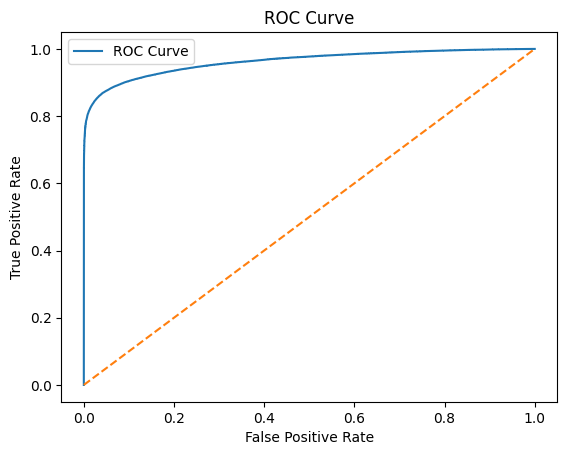

In [53]:
#ROC Curve

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()